# Lab 2 &mdash; Fourier transform

## Submission rules:

1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file) downloaded from your team's Google Colab. Make sure you made a copy of the notebook above and opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **cms**.
2. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
3. This time, you also need to provide a **work breakdown structure** estimating the efforts of each team member. Please provide it at the top of your notebook.
4. This lab requires some visualization from you; please arrange it according to best practices (appropriate axes labels, title, size/scale are a minimum).
5. The final deadline is **March 17 2025, 23:59**. Making any changes to your code after this time and date is forbidden and will be a reason for point deduction for the whole team.

#### Work breakdown:

1. **Arsenii Stratiuk**:

   **Task 1.1**: Apply FFT to the sinusoid example and plot the frequency-domain representation.

   **Task 1.2**: Identify the frequencies of the component signals and explain how FFT separates them.

## Introduction
Soon, you will learn about Fourier transform, i.e., an operator that maps functions depending on space (resp. time) variables into functions depending on spatial (resp. temporal) frequency, which is widely used in spectroscopy and signal processing.  

One of the motivations to use Fourier transform comes from the study of Fourier series. In our particular case, you will transform sound (a continuous wave that is a mixture of multiple frequencies) into an arrray of pure frequencies that can be analyzed with the help of Discrete Fourier Transform. The ultimate goal is to decompose a melody into a sequence of pitches and then to notes (without any help of a trained musician's ear &mdash; that would be cheating!).

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from IPython.display import Audio
%matplotlib inline

## Sinusoids

Let's first consider a simple example. Decompose a series sin3 that is a sum of two sinusoids using the Fast Fourier transform from scipy library. FFT is simply a computationally efficient implementation of a discrete Fourier transform. What is the frequency of sin1 and sin2 signals?

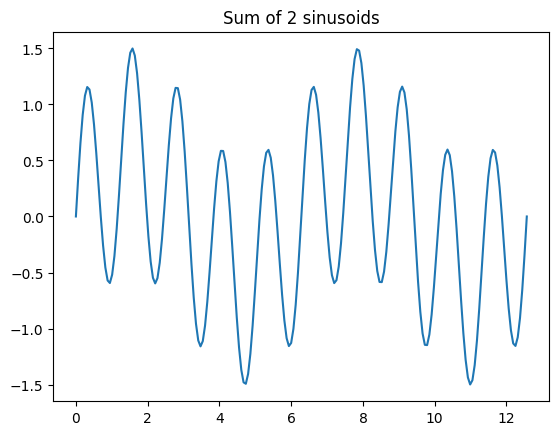

In [2]:
x = np.linspace(0, 4*np.pi, 200)
sin1 = 0.5 * np.sin(x)
sin2 = np.sin(5*x)
sin3 = sin1 + sin2
plt.plot(x, sin3)
plt.title('Sum of 2 sinusoids')
plt.show()


Apply FFT to sin3 series to obtain frequency decomposition and plot the results.

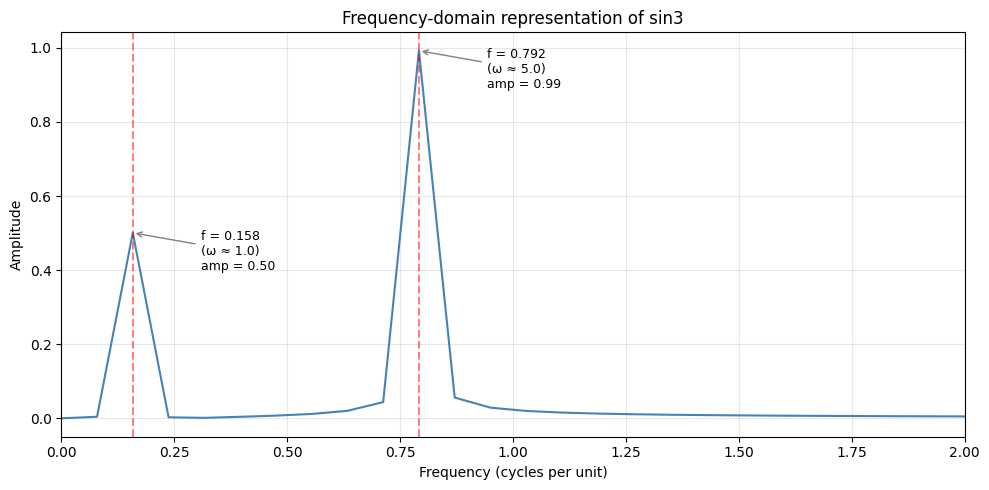

In [4]:
N = len(sin3)
T = x[1] - x[0]

yf = fft(sin3)
xf = fftfreq(N, T)

amplitudes = 2.0/N * np.abs(yf[:N//2])
freqs = xf[:N//2]

peak_indices = np.where(amplitudes > 0.1)[0]
peak_freqs = freqs[peak_indices]
peak_amps = amplitudes[peak_indices]

plt.figure(figsize=(10, 5))
plt.plot(freqs, amplitudes, color='steelblue')

for pf, pa in zip(peak_freqs, peak_amps):
    omega = pf * 2 * np.pi
    plt.axvline(x=pf, color='red', linestyle='--', alpha=0.5)
    plt.annotate(f'f = {pf:.3f}\n(ω ≈ {omega:.1f})\namp = {pa:.2f}',
                 xy=(pf, pa), xytext=(pf + 0.15, pa - 0.1),
                 fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Frequency (cycles per unit)')
plt.ylabel('Amplitude')
plt.title('Frequency-domain representation of sin3')
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Make sure that you got 2 spikes corresponding to the frequencies that we assigned to the sinusoids earlier. Explain how the transformation is conducted and why we can obtain two perfectly separated frequencies from a mixed signal.



---

**Identifying the two frequencies.** The plot shows two clear spikes. The first one is at frequency $f \approx 0.159$ with amplitude $\approx 0.5$, the second at $f \approx 0.796$ with amplitude $\approx 1.0$. These correspond to the angular frequencies $\omega = 1$ and $\omega = 5$ of the orignal signals, because $f = \omega / (2\pi)$: so $1/(2\pi) \approx 0.159$ and $5/(2\pi) \approx 0.796$. The amplitudes also match - `sin1` was multiplied by 0.5, `sin2` by 1.0.

**How FFT works - the idea.** The Discrete Fourier Transform checks, for each possible frequency, how strongly that frequency is present in our signal. The way it does this is surprisingly simple: it takes a "test wave" at that frequency, multiplies it point-by-point with our signal, and sums all the products.

Here is a small example. Say we have just 4 samples of some signal: $[1, 0, -1, 0]$. This pattern repeats once over 4 points, so it is a wave of frequency 1. If we test frequency 1, the test wave is also $[1, 0, -1, 0]$. We mutliply each pair and sum: $1 \cdot 1 + 0 \cdot 0 + (-1)(-1) + 0 \cdot 0 = 2$. Big positive number - frequency 1 is there. Now test frequency 2 (test wave: $[1, -1, 1, -1]$): $1 \cdot 1 + 0 \cdot (-1) + (-1) \cdot 1 + 0 \cdot (-1) = 0$. Zero - frequency 2 is absent. This is the core of Fourier analysis: matching frequencies give large sums, non-matching ones cancel to zero.

**The DFT formula.** Written compactly, this multiply-and-sum procedure for frequency $k$ is:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-i \, 2\pi \, k \, n \,/\, N}$$

where:
- $x[n]$ is the $n$-th sample of our signal (for us, the $n$-th value of `sin3`)
- $N$ is the total number of samples (200 in our case)
- $k$ is which frequency we are testing
- $e^{-i \, 2\pi \, k \, n / N}$ is the test wave value at position $n$ for frequency $k$

The test wave part uses Euler's formula: $e^{i\theta} = \cos(\theta) + i\sin(\theta)$. So $e^{-i \, 2\pi kn/N} = \cos(2\pi kn/N) - i\sin(2\pi kn/N)$. This bundles cosine and sine into one expression. Why both are needed: a cosine test wave would miss a signal that happens to be pure sine (since sine is cosine shifted by 90°). By testing with both cosine and sine at the same time, we catch any wave at frequency $k$ regardless of its phase shift.

Each result $X[k]$ is a complex number. Its magnitude $|X[k]| = \sqrt{\text{real}^2 + \text{imaginary}^2}$ tells us the strength of that frequency. That is what we plotted.

**Why are there only finitely many frequencies to test?** Since we have $N$ discrete samples, there are only $N$ distinguishable test waves. A test wave must complete a whole number of cycles across our $N$ points: 0 cycles (constant), 1 cycle, 2 cycles, ..., up to $N/2$ cycles. Past $N/2$ cycles, each cycle would need fewer than 2 points to describe it, which is not enough (you need at least an "up" and a "down"). So the maximum testable frequency is $N/2$ - this limit is known as the Nyquist frequency. In practice FFT returns $N$ values, but the second half mirrors the first, so we only look at the first $N/2$.

**Why do the frequencies separate perfectly?** Because sinusoids at different frequencies are orthogonal - when you multiply two sinusoids of different frequencies and sum over a full period, the positives and negatives always cancel to zero. So the test for frequency $f_1$ is not affected by the presence of frequency $f_2$ in the signal. I found this tricky because in the time-domain plot the waves look completley mixed together, but the math guarantees a clean split.

---

## Working with example audio

Now, let's work with a more complex wave&mdash;sound. Any sound (audio signal) can be characterized by the following three quantities: Pitch, Quality, and Loudness.

Loudness is a physiological sensation that depends mainly on the sound wave pressure (amplitude).

The lowest note in a chord is called fundamental. It is heard predominantly due to larger intensity. Quality is determined by overtones or harmonics that add to the sound of a fundamental note.

Pitch is the frequency of a sound as perceived by human ear. A high frequency gives rise to a high pitch note and a low frequency produces a low pitch note. A pure tone is the sound of only one frequency, such as that given by a tuning fork or electronic signal generator. Naturally, music does not consist of pure tones. Depending on an instrument, technique and many other factors, sound will decay at different rates and one tone will mix with the other ones.

Thus, transcribing audio files into standard music notation (i.e., the notes) is a non-trivial task. We will focus on recognizing pitches and matching them to notes.

### Load and explore

In [ ]:
# Load first sound from library examples
# Monophonic trumpet recording
trumpet_path = librosa.example('trumpet')
Audio(trumpet_path)

In [ ]:
trumpet_sample, trumpet_sampling_rate = librosa.load(trumpet_path)

What is a sampling rate? What does sampling rate imply about the audio? Is it sufficient for our task (according to https://en.wikipedia.org/wiki/Nyquist%E2%80%93Shannon_sampling_theorem)?


---
>**Your explanations here**

---

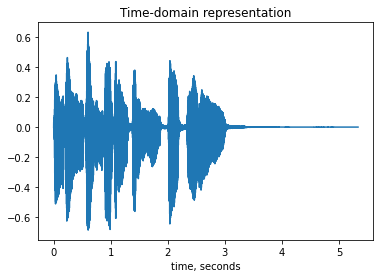

In [ ]:
# Initial visualization
time = np.array(range(trumpet_sample.shape[0])) / trumpet_sampling_rate
plt.plot(time, trumpet_sample)
plt.title('Time-domain representation')
plt.xlabel('time, seconds')
plt.show()

This visualization is called the time-domain representation of a given signal. This shows us the loudness (amplitude) of sound wave changing with time. Here amplitude = 0 represents silence. These amplitudes are not very informative as they only represent the loudness of audio recording. To better understand the audio signal, it is necessary to transform it into the frequency domain. The frequency-domain representation of a signal tells us which frequencies are present in the signal.

Decompose the trumpet samples using fft and plot the results. Observe that the frequency pattern corresponds to the pitch changes.

In [ ]:
# FFT for trumpet

## Analyzing a song

In the next task, you need to use the recording of a famous Ukrainian song (piano_melody.mp3) attached on cms. Your creativity is not limited here so any better ways to compelling visuals, more advanced algorithms on top of FFT or spectrogram, and explanations will be rewarded.     


1.   Load the recording, replay it, and plot in the time domain. To get a better view of how the notes change throughout a shorter time, choose a sample of the audio up to 5 seconds and plot it in the time domain. From here on out you will be working with this smaller 5-second sample.


In [ ]:
# Loading sound
path = # your path
samples, sampling_rate = librosa.load(path)
Audio(path)
#Creating a 5-second sample of the audio
samples = samples[...]

2.   Build a spectrogram of the sample. Explain what domain the spectrogram represents us and how can it be useful.


In [ ]:
# Your code here

---
>**Your explanations here**

---

3.   Transform signal to the frequency domain with FFT and study the distribution of pitches (frequencies).
Observe that the melody contains only a couple of distinct sounds, but there are a lot more spikes in the frequency domain.

In [ ]:
# Your code here

4. Apply averaging to the initial signal. Averaging is a procedure that reduces number of samples by taking mean of each n of our samples. Experiment with n and determine whichever will work best to both reduce the noise and not loose any information. You can propose other ways to efficiently denoise the signal.

In [ ]:
# Your code here

---
>**Your explanations here**

---

5. Match fundamental pitches you discovered to the standard note frequencies and display them in a table like the one outlined below.

|Detected frequency(Hz) | Assigned frequency(Hz) | Output note|   
|:---------------------:|:----------------------:|:----------:|
|393.2 |391.9| G4  

In [ ]:
# Your code here

In the last task you will use the recording of Lynyrd Skynyrd - Free Bird.

6.    Experiment with filtering of free_bird.mp3 using Butterworth filter (or other ways which you prefer), so that only bass could be heard. (Hint: you can use [scipy.signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)). Replay original and filtered audios. Plot their time and frequency domains.

In [ ]:
free_bird_path = # your path
free_bird_samples, free_bird_sampling_rate = librosa.load(free_bird_path)
# Your code here

---
>**Your explanations here**

---

## Summary

1. What is Fourier transform? How can it be used in signal processing?


2. What are time and frequency domains and how can they be useful?

3. What is averaging and what is its purpose?